# Keyword Hierarchy Builder
Builds a multi-level keyword tree around a topic using an LLM.
Results are cached to disk so repeated queries are free and reviewable.

## 1. Imports & Setup

import os
import sys
import json
import hashlib
import re
import time
from datetime import datetime, timezone
from pathlib import Path
from datetime import datetime

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

from tova.prompter import Prompter

In [1]:
import os
import sys
import json
import hashlib
import time
from datetime import datetime, timezone
from pathlib import Path
from datetime import datetime

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append('..')
from src.prompter import Prompter

## 2. Configuration

In [ ]:
# ── LLM config ──────────────────────────────────────────────────────────────
MODEL_TYPE   = "qwen3:32b"
#CONFIG_PATH  = "static/config/config.yaml"
CONFIG_PATH  = "../config.yaml"

# ── Query parameters ────────────────────────────────────────────────────────
ROOT_TOPIC   = "living lab"   # Starting topic
N_KEYWORDS   = 10         # Keywords requested per query
N_KEYWORDS_2 = 7         # Keywords requested per query for levels > 1
MAX_LEVELS   = 5          # How many levels deep to expand (0 = root only)

# ── Cache config ────────────────────────────────────────────────────────────
CACHE_DIR    = Path("new_query_cache")
CACHE_DIR.mkdir(exist_ok=True)

# ── Initialise prompter ─────────────────────────────────────────────────────
prompter = Prompter(config_path=CONFIG_PATH, model_type=MODEL_TYPE, temperature=0.3)

src.prompter - INFO - Setting temperature to: 0.3
src.prompter - INFO - Using yiyuan host: https://yiyuan.tsc.uc3m.es
src.prompter - INFO - Using yiyuan API with host: https://yiyuan.tsc.uc3m.es


Loaded config file ../config.yaml and section logger.
Logs will be saved in data/logs
Loaded config file ../config.yaml and section llm.


## 3. Cache Helpers
Every LLM call is saved as a JSON file keyed by `topic + n_keywords`.
Re-running the notebook skips cached topics automatically.

In [3]:
def _cache_key(topic: str, n_keywords: int) -> str:
    """Stable filename key for a (topic, n_keywords) pair."""
    raw = f"{topic.strip().lower()}_{n_keywords}"
    return hashlib.md5(raw.encode()).hexdigest()[:12] + f"__{topic.strip().lower().replace(' ', '_')}"


def cache_path(topic: str, n_keywords: int) -> Path:
    return CACHE_DIR / f"{_cache_key(topic, n_keywords)}.json"


def load_cache(topic: str, n_keywords: int) -> dict | None:
    """Return cached result dict or None if not found."""
    p = cache_path(topic, n_keywords)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None


def save_cache(topic: str, n_keywords: int, raw_response: str, parsed: dict) -> None:
    record = {
        "topic": topic,
        "n_keywords": n_keywords,
        "timestamp": datetime.now(timezone.utc).isoformat(),  # fixed deprecation
        "raw_response": raw_response,
        "parsed": parsed,
    }
    with open(cache_path(topic, n_keywords), "w") as f:
        json.dump(record, f, indent=2)


def invalidate_cache(topic: str, n_keywords: int) -> None:
    """Delete a cached entry to force a fresh LLM call."""
    p = cache_path(topic, n_keywords)
    if p.exists():
        p.unlink()
        print(f"Cache cleared for '{topic}'.")
    else:
        print(f"No cache entry found for '{topic}'.")


def list_cache() -> pd.DataFrame:
    """Show every cached query as a DataFrame for easy review."""
    records = []
    for p in sorted(CACHE_DIR.glob("*.json")):
        with open(p) as f:
            rec = json.load(f)
        records.append({
            "file": p.name,
            "topic": rec["topic"],
            "n_keywords": rec["n_keywords"],
            "timestamp": rec["timestamp"],
            "n_parsed_keys": len(rec["parsed"]),
        })
    return pd.DataFrame(records) if records else pd.DataFrame(columns=["file","topic","n_keywords","timestamp","n_parsed_keys"])


print("Cache helpers loaded. Cache directory:", CACHE_DIR.resolve())

Cache helpers loaded. Cache directory: /export/usuarios_ml4ds/danibacaicoa/Keywords_living/Living_keywords/Notebooks/new_query_cache


## 4. Core Functions

In [4]:
DOMAIN_DEFINITIONS = {
    "living lab": {
        "full": (
            "A Living Lab is a real-world open innovation ecosystem where citizens, researchers, "
            "companies, and governments co-create and test solutions in everyday life contexts."
        ),
        "dimensions": [
            "real-world testing and experimentation contexts",
            "open innovation processes and methodologies",
            "multi-actor collaboration (citizens, researchers, companies, governments)",
            "co-creation and participatory design methodologies",
            "everyday life application and urban/social contexts",
        ]
    }
}

def build_prompt(topic: str, n_keywords: int, root_topic: str = "") -> str:
    is_root = not root_topic or topic == root_topic
    domain_def = DOMAIN_DEFINITIONS.get(topic if is_root else root_topic, None)

    if domain_def:
        if is_root:
            definition_block = f"\nTOPIC DEFINITION: {domain_def['full']}\n"
        else:
            dims = "\n".join(f"  - {d}" for d in domain_def["dimensions"])
            definition_block = f"""
SCORING CRITERIA: A keyword scores 8-10 only if it directly relates to at least 
one of these dimensions:
{dims}
Keywords unrelated to these dimensions should score 1-3 at most.
"""
    else:
        definition_block = ""

    return f"""You are a JSON-only output machine. You never write explanations, greetings, or markdown.
TASK: Given the topic "{topic}", return exactly {n_keywords} related keywords with specificity scores.
{definition_block}
RULES (violations will break the system):
1. Output MUST start with {{ and end with }} — nothing before, nothing after
2. The topic itself must appear first with score 0
3. No keyword may contain the topic word "{topic}"
4. All keywords must be unique
5. Scores are integers 1-10 only (topic gets 0)
6. No markdown, no ```json, no explanations, no trailing text
SCORING:
  8-10 → direct synonyms or highly specific sub-concepts
  4-7  → broadly related fields or associated concepts  
  1-3  → loose umbrella terms
TOPIC: {topic}
OUTPUT (raw JSON only):
{{
  "{topic}": 0,
  "keyword1": score,
  "keyword2": score
}}"""

def extract_dictionary(response: str) -> dict:
    """Strip optional markdown fences and parse JSON."""
    #clean = response.strip()
    clean = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()

    if clean.startswith("```json"):
        clean = clean[7:]
    elif clean.startswith("```"):
        clean = clean[3:]
    if clean.endswith("```"):
        clean = clean[:-3]
    return json.loads(clean.strip())

def validate_keywords(parsed: dict, topic: str) -> None:
    """Raise ValueError if the parsed dict violates the expected contract."""

    if topic not in parsed:
        raise ValueError(f"Topic '{topic}' missing. Got: {list(parsed.keys())}")
    if parsed[topic] != 0:
        raise ValueError(f"Topic '{topic}' has score {parsed[topic]}, expected 0")
    if len(parsed) < 2:
        raise ValueError(f"Only {len(parsed)} entries returned, expected at least 2")

    topic_lower = topic.lower()
    for kwd, score in parsed.items():
        if kwd == topic:
            continue
        if not isinstance(score, int):
            raise ValueError(f"Score for '{kwd}' is {type(score).__name__}, expected int")
        if not (1 <= score <= 10):
            raise ValueError(f"Score {score} for '{kwd}' is out of range [1, 10]")
        # Only block if the FULL topic phrase appears inside the keyword
        if topic_lower in kwd.lower():
            raise ValueError(f"Keyword '{kwd}' contains the full topic phrase '{topic}'")



def get_keywords(topic: str, n_keywords: int, prompter,
                 root_topic: str = "",
                 use_cache: bool = True, max_retries: int = 3) -> dict:
    
    if use_cache:
        cached = load_cache(topic, n_keywords)
        if cached is not None:
            return cached["parsed"]

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            prompt = build_prompt(topic, n_keywords, root_topic=root_topic)
            
            print(prompt)
            
            raw    = prompter.prompt(question=prompt, system_prompt_template_path=None)[0]
            
            print("// Raw LLM response:")
            
            print(raw)
            
            parsed = extract_dictionary(raw)
            
            # Validate the result makes sense before accepting it
            validate_keywords(parsed, topic)
            
            save_cache(topic, n_keywords, raw, parsed)
            return parsed

        except Exception as e:
            last_error = e
            print(f"  Attempt {attempt}/{max_retries} failed for '{topic}': {e}")
            time.sleep(1 * attempt)  # simple backoff

    # Save the last bad response for inspection
    bad_path = CACHE_DIR / f"FAILED__{topic.replace(' ', '_')}.txt"
    bad_path.write_text(raw)
    raise RuntimeError(
        f"All {max_retries} attempts failed for '{topic}'. "
        f"Last error: {last_error}. Raw response saved to {bad_path}"
    )


def df_from_dict(dictionary: dict, level: int) -> pd.DataFrame:
    """
    Convert a keyword dict into a DataFrame row-set.

    - The topic entry (score == 0) is included only at level 0
      (it is already present from a parent call at deeper levels).
    - All other entries become children of the root keyword.
    """
    root_kwd = next(k for k, v in dictionary.items() if v == 0)

    rows = []
    for kwrd, score in dictionary.items():
        if score == 0:
            if level == 0:          # include root node only at the first level
                rows.append({"kwrd": kwrd, "lvl": 0, "parent": None, "score": 0})
        else:
            rows.append({"kwrd": kwrd, "lvl": level + 1, "parent": root_kwd, "score": score})

    return pd.DataFrame(rows)


print("Core functions defined.")

Core functions defined.


def build_prompt(topic: str, n_keywords: int) -> str:
    return f"""
I will give you a topic. You need to provide the {n_keywords} most related keywords to this topic.
If there are fewer than {n_keywords} valid keywords available, output only the ones that exist.
Never repeat a keyword for a given topic. All keywords must be unique.

CRITICAL RULE: None of the generated keywords may contain the topic word(s) itself.
For example, if the topic is "cancer", keywords like "cancer treatment" or "lung cancer" are
strictly forbidden. You must find distinct related terms (e.g., "oncology", "tumor", "chemotherapy").

For each keyword, assign a specificity score — a natural number between 1 and 10 inclusive.
You must also include the original topic itself in the output with a score of exactly 0.

Scoring Rubric:
  8-10 (Highly Specific)  : Direct synonyms or granular concepts exclusive to the topic.
  4-7  (Moderately Related): Broadly related fields, symptoms, or associated concepts.
  1-3  (Loosely Related)  : High-level umbrella terms or vague associations.

Topic: {topic}

Return the result as a single, flat JSON dictionary where keys are words and values are integer
scores, ordered from most specific (highest) to least specific (lowest), with the topic at the top:
{{
  "{topic}": 0,
  "keyword1": score_1,
  "keyword2": score_2
}}

Do NOT output markdown formatting, code blocks, or extra text. Output ONLY the raw JSON.
"""


def extract_dictionary(response: str) -> dict:
    """Strip optional markdown fences and parse JSON."""
    clean = response.strip()
    if clean.startswith("```json"):
        clean = clean[7:]
    elif clean.startswith("```"):
        clean = clean[3:]
    if clean.endswith("```"):
        clean = clean[:-3]
    return json.loads(clean.strip())


def get_keywords(topic: str, n_keywords: int, prompter, use_cache: bool = True) -> dict:
    """
    Query the LLM for keywords related to *topic*.
    Results are cached; set use_cache=False to force a fresh call.

    Returns the parsed keyword dict  {word: score, ...}
    """
    if use_cache:
        cached = load_cache(topic, n_keywords)
        if cached is not None:
            return cached["parsed"]

    prompt   = build_prompt(topic, n_keywords)
    raw      = prompter.prompt(prompt)[0]
    parsed   = extract_dictionary(raw)
    save_cache(topic, n_keywords, raw, parsed)
    return parsed


def df_from_dict(dictionary: dict, level: int) -> pd.DataFrame:
    """
    Convert a keyword dict into a DataFrame row-set.

    - The topic entry (score == 0) is included only at level 0
      (it is already present from a parent call at deeper levels).
    - All other entries become children of the root keyword.
    """
    root_kwd = next(k for k, v in dictionary.items() if v == 0)

    rows = []
    for kwrd, score in dictionary.items():
        if score == 0:
            if level == 0:          # include root node only at the first level
                rows.append({"kwrd": kwrd, "lvl": 0, "parent": None, "score": 0})
        else:
            rows.append({"kwrd": kwrd, "lvl": level + 1, "parent": root_kwd, "score": score})

    return pd.DataFrame(rows)


print("Core functions defined.")

## 5. Build Keyword Tree
Runs LLM queries level-by-level and accumulates results in `df`.

In [6]:
import re
root_dict = get_keywords(topic=ROOT_TOPIC, n_keywords=N_KEYWORDS, prompter=prompter)
df = df_from_dict(root_dict, level=0)

for lvl in range(1, 3):
    level_keywords = df[df["lvl"] == lvl]["kwrd"].tolist()
    for kwd in tqdm(level_keywords, desc=f"Level {lvl} keywords"):
        #kwd_dict = get_keywords(kwd, N_KEYWORDS_2, prompter)
        #kwd_dict = get_keywords(topic=kwd, n_keywords=N_KEYWORDS_2, prompter=prompter, root_topic=ROOT_TOPIC)
        kwd_dict = get_keywords(topic=kwd, n_keywords=3, prompter=prompter, root_topic=ROOT_TOPIC)

        df_new   = df_from_dict(kwd_dict, level=lvl)
        df       = pd.concat([df, df_new], ignore_index=True)

print(f"\nDone! Tree has {len(df)} rows across {df['lvl'].max() + 1} levels.")
df

You are a JSON-only output machine. You never write explanations, greetings, or markdown.
TASK: Given the topic "living lab", return exactly 10 related keywords with specificity scores.

TOPIC DEFINITION: A Living Lab is a real-world open innovation ecosystem where citizens, researchers, companies, and governments co-create and test solutions in everyday life contexts.

RULES (violations will break the system):
1. Output MUST start with { and end with } — nothing before, nothing after
2. The topic itself must appear first with score 0
3. No keyword may contain the topic word "living lab"
4. All keywords must be unique
5. Scores are integers 1-10 only (topic gets 0)
6. No markdown, no ```json, no explanations, no trailing text
SCORING:
  8-10 → direct synonyms or highly specific sub-concepts
  4-7  → broadly related fields or associated concepts  
  1-3  → loose umbrella terms
TOPIC: living lab
OUTPUT (raw JSON only):
{
  "living lab": 0,
  "keyword1": score,
  "keyword2": score
}
<thin

Level 1 keywords:   0%|          | 0/10 [00:00<?, ?it/s]

You are a JSON-only output machine. You never write explanations, greetings, or markdown.
TASK: Given the topic "open innovation", return exactly 3 related keywords with specificity scores.

SCORING CRITERIA: A keyword scores 8-10 only if it directly relates to at least 
one of these dimensions:
  - real-world testing and experimentation contexts
  - open innovation processes and methodologies
  - multi-actor collaboration (citizens, researchers, companies, governments)
  - co-creation and participatory design methodologies
  - everyday life application and urban/social contexts
Keywords unrelated to these dimensions should score 1-3 at most.

RULES (violations will break the system):
1. Output MUST start with { and end with } — nothing before, nothing after
2. The topic itself must appear first with score 0
3. No keyword may contain the topic word "open innovation"
4. All keywords must be unique
5. Scores are integers 1-10 only (topic gets 0)
6. No markdown, no ```json, no explanation

Level 1 keywords:  10%|█         | 1/10 [05:16<47:29, 316.65s/it]

<think> in reponse: <think>
Okay, let's tackle this. The user wants three related keywords to "open innovation" with specific scores based on the given criteria. First, I need to remember the rules. The topic itself is first with a 0. No keyword can include "open innovation". All must be unique, and scores are integers 1-10.

Looking at the scoring criteria, keywords that directly relate to the dimensions get 8-10. The dimensions include real-world testing, processes/methodologies, multi-actor collaboration, co-creation, and everyday applications. So I need to think of terms that fit these areas.

First, "crowdsourcing" comes to mind. It's a process where companies or organizations get ideas from the public. That fits under multi-actor collaboration and open innovation processes. So that's probably an 8-10. 

Next, "co-creation" is directly mentioned in the criteria as a dimension. It's a methodology where users or stakeholders are involved in creating products or services. That should

...

Level 2 keywords:  77%|███████▋  | 23/30 [22:25<09:35, 82.25s/it]

<think> in reponse: <think>
Okay, let's tackle this. The user wants three related keywords to "cross-sector partnerships" with specific scores based on the given criteria. First, I need to remember the scoring rules. Keywords that directly relate to the five dimensions mentioned (real-world testing, open innovation, multi-actor collaboration, co-creation, everyday application) should get 8-10. Others get lower.

Starting with the topic itself, it's given a 0. Now, the first keyword. Multi-actor collaboration is one of the dimensions. So "multi-actor collaboration" would be a direct sub-concept. That should be an 8-10. Let's go with 9.

Next, co-creation methodologies. That's another dimension. So "co-creation methodologies" would fit here. Maybe a 9 as well.

Third, open innovation processes. That's one of the dimensions too. So "open innovation processes" could be another 9. Wait, but the user said no keyword can contain the topic word. The topic is "cross-sector partnerships," so the

Level 2 keywords: 100%|██████████| 30/30 [22:33<00:00, 45.10s/it]

<think> in reponse: <think>
Okay, let's tackle this. The user wants three related keywords to "living labs" with specific scores based on the given criteria. First, I need to remember the scoring rules. The keywords must relate to real-world testing, open innovation, multi-actor collaboration, co-creation, or everyday applications. Each keyword should be unique and not include "living labs".

Starting with real-world testing. A term that comes to mind is "field trials". That's directly about testing in real environments, so that's a strong candidate for 8-10. Next, open innovation processes. "Open innovation" itself is a key term here. It's directly related, so maybe a 9. Then, multi-actor collaboration. "Stakeholder engagement" fits because it involves various actors working together. That's another 8-10. Let me check if these are unique and don't include the topic. Yes, they are. Now, assigning scores. Field trials: 9, Open innovation: 10, Stakeholder engagement: 9. That should meet 

,kwrd,lvl,parent,score
0,living lab,0,NaN,0
1,open innovation,1,living lab,9
2,user-centered design,1,living lab,8
3,co-creation,1,living lab,9
4,real-world testing,1,living lab,8
...,...,...,...,...
126,open innovation,3,co-creation,9
127,multi-actor collaboration,3,co-creation,9
128,crowdsourcing,3,open innovation,9
129,co-creation,3,open innovation,10


In [7]:
df

,kwrd,lvl,parent,score
0,living lab,0,NaN,0
1,open innovation,1,living lab,9
2,user-centered design,1,living lab,8
3,co-creation,1,living lab,9
4,real-world testing,1,living lab,8
...,...,...,...,...
126,open innovation,3,co-creation,9
127,multi-actor collaboration,3,co-creation,9
128,crowdsourcing,3,open innovation,9
129,co-creation,3,open innovation,10


In [13]:
# ── Seed: root topic ────────────────────────────────────────────────────────
root_dict = get_keywords(ROOT_TOPIC, N_KEYWORDS, prompter)
df = df_from_dict(root_dict, level=0)

# ── Expand level by level ───────────────────────────────────────────────────
for lvl in range(1, MAX_LEVELS):
    level_keywords = df[df["lvl"] == lvl]["kwrd"].tolist()
    for kwd in tqdm(level_keywords, desc=f"Level {lvl} keywords"):
        kwd_dict = get_keywords(kwd, N_KEYWORDS_2, prompter)
        df_new   = df_from_dict(kwd_dict, level=lvl)
        df       = pd.concat([df, df_new], ignore_index=True)

print(f"\nDone! Tree has {len(df)} rows across {df['lvl'].max() + 1} levels.")
df

Level 2 keywords:   0%|          | 0/70 [00:00<?, ?it/s]

You are a JSON-only output machine. You never write explanations, greetings, or markdown.
TASK: Given the topic "open source", return exactly 7 related keywords with specificity scores.

RULES (violations will break the system):
1. Output MUST start with { and end with } — nothing before, nothing after
2. The topic itself must appear first with score 0
3. No keyword may contain the topic word "open source"
4. All keywords must be unique
5. Scores are integers 1-10 only (topic gets 0)
6. No markdown, no ```json, no explanations, no trailing text
SCORING:
  8-10 → direct synonyms or highly specific sub-concepts
  4-7  → broadly related fields or associated concepts  
  1-3  → loose umbrella terms
TOPIC: open source
OUTPUT (raw JSON only):
{
  "open source": 0,
  "keyword1": score,
  "keyword2": score
}
<think> in reponse: <think>
Okay, let's tackle this. The user wants me to generate 7 related keywords to "open source" with specific scores. The rules are strict, so I need to be careful.


Level 2 keywords:   1%|▏         | 1/70 [00:06<06:54,  6.01s/it]


RuntimeError: All 3 attempts failed for 'open source'. Last error: Keyword 'open source license' contains the full topic phrase 'open source'. Raw response saved to new_query_cache/FAILED__open_source.txt

In [6]:
kwd

'hands-on experience'

## 6. Review Cache
Inspect every stored query. You can re-run a query by calling `invalidate_cache(topic, n_keywords)` and re-executing section 5.

In [8]:
list_cache()

,file,topic,n_keywords,timestamp,n_parsed_keys
0,0063d9c03d7d__tech_incubator.json,tech incubator,7,2026-03-16T11:16:24.177786+00:00,8
1,006f4f3856e2__collaborative_research.json,collaborative research,7,2026-03-16T11:14:04.767897+00:00,8
2,00b58fb5bc38__test_environment.json,test environment,7,2026-03-16T11:20:40.675990+00:00,8
3,02bba9a7d56d__digital_outreach_tools.json,digital outreach tools,7,2026-03-16T11:29:26.570353+00:00,8
4,06e24bf73cee__cross-functional_teams.json,cross-functional teams,7,2026-03-16T11:26:09.125604+00:00,8
...,...,...,...,...,...
70,f1a6753db323__participatory_governance.json,participatory governance,7,2026-03-16T11:30:32.304457+00:00,8
71,f3ce782317b4__development_platform.json,development platform,7,2026-03-16T11:21:34.552603+00:00,8
72,fdc3a014bef0__experimental_testbed.json,experimental testbed,7,2026-03-16T11:13:23.051163+00:00,8
73,ff678095c803__innovation_hub.json,innovation hub,7,2026-03-16T11:13:00.273876+00:00,8


In [9]:
# Inspect a specific cached response in full
REVIEW_TOPIC = ROOT_TOPIC

cached = load_cache(REVIEW_TOPIC, N_KEYWORDS)
if cached:
    print(f"Topic     : {cached['topic']}")
    print(f"Timestamp : {cached['timestamp']}")
    print(f"\nRaw LLM response:\n{cached['raw_response']}")
    print(f"\nParsed dict:")
    display(pd.DataFrame(list(cached['parsed'].items()), columns=['keyword','score']))
else:
    print("No cache entry found.")

Topic     : living lab
Timestamp : 2026-05-19T14:38:38.583000+00:00

Raw LLM response:
{
  "living lab": 0,
  "open innovation": 9,
  "user-centered design": 8,
  "co-creation": 9,
  "real-world testing": 8,
  "participatory design": 7,
  "collaborative innovation": 7,
  "field testing": 8,
  "community engagement": 7,
  "innovation ecosystem": 6,
  "stakeholder collaboration": 7
}

Parsed dict:


,keyword,score
0,living lab,0
1,open innovation,9
2,user-centered design,8
3,co-creation,9
4,real-world testing,8
5,participatory design,7
6,collaborative innovation,7
7,field testing,8
8,community engagement,7
9,innovation ecosystem,6


## 7. Graph Visualisation

/tmp/ipykernel_2859341/186654639.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


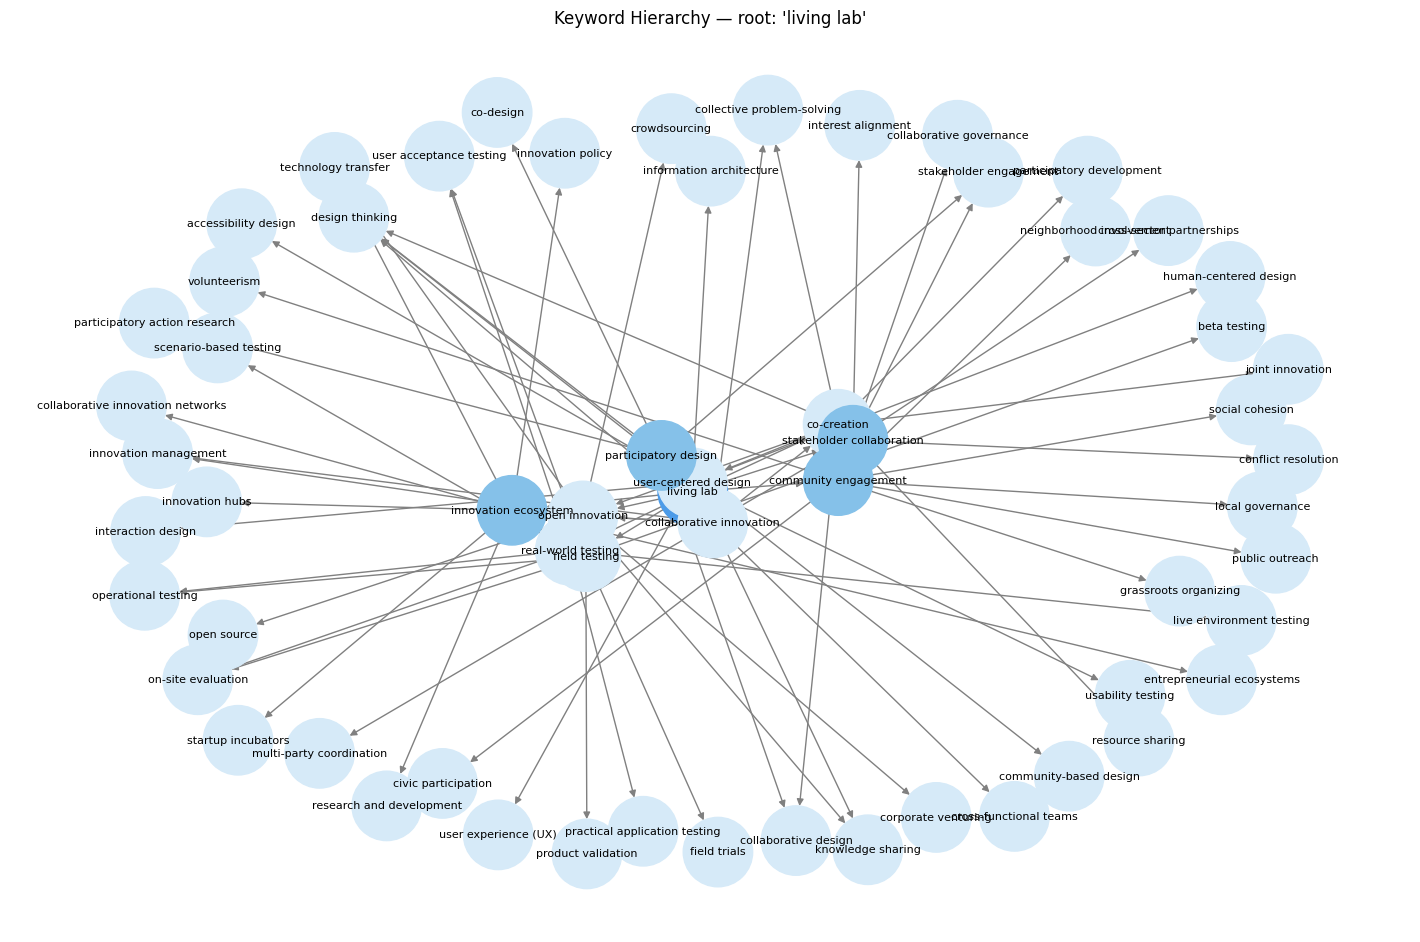

In [14]:
G = nx.DiGraph()

for _, row in df.dropna(subset=["parent"]).iterrows():
    G.add_edge(row["parent"], row["kwrd"], weight=row["score"])

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42)

# Colour nodes by level
level_map  = df.set_index("kwrd")["lvl"].to_dict()
node_colors = ["#4C9BE8" if level_map.get(n, 1) == 0
               else "#85C1E9" if level_map.get(n, 1) == 1
               else "#D6EAF8"
               for n in G.nodes()]

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    edge_color="gray",
    font_size=8,
    arrows=True,
)
plt.title(f"Keyword Hierarchy — root: '{ROOT_TOPIC}'")
plt.tight_layout()
plt.show()

In [15]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import plotly.graph_objects as go
from datetime import datetime, timezone

# ── 1. PageRank (node importance) ───────────────────────────────────────────
personalization = {n: (1 if n == ROOT_TOPIC else 0) for n in G.nodes()}
ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="score")

# ── 2. Community detection (Louvain on undirected projection) ───────────────
G_undirected = G.to_undirected()
communities  = nx_comm.louvain_communities(G_undirected, seed=42)
node_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i

PALETTE = [
    "#378ADD", "#1D9E75", "#D85A30",
    "#7F77DD", "#BA7517", "#D4537E",
    "#639922", "#888780",
]

# ── 3. Layout (kamada-kawai respects edge weights) ───────────────────────────
pos = nx.kamada_kawai_layout(G, weight="weight")

# ── 4. Build edge traces (opacity = normalised edge weight) ──────────────────
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
w_min, w_max = min(all_weights), max(all_weights)

edge_traces = []
for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    opacity = 0.15 + 0.65 * (data["weight"] - w_min) / max(w_max - w_min, 1)
    edge_traces.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode="lines",
        line=dict(width=1, color=f"rgba(120,120,120,{opacity:.2f})"),
        hoverinfo="none",
        showlegend=False,
    ))

# ── 5. Build node traces (one per community for legend) ──────────────────────
node_traces = []
for comm_id, community in enumerate(communities):
    nodes  = list(community)
    color  = PALETTE[comm_id % len(PALETTE)]
    xs     = [pos[n][0] for n in nodes]
    ys     = [pos[n][1] for n in nodes]
    sizes  = [10 + ppr[n] * 8000 for n in nodes]
    labels = [
        f"<b>{n}</b><br>PPR: {ppr[n]:.4f}<br>Score: {df[df['kwrd']==n]['score'].max()}<br>Level: {df[df['kwrd']==n]['lvl'].min()}<br>Community: {comm_id}"
        for n in nodes
    ]
    node_traces.append(go.Scatter(
        x=xs, y=ys,
        mode="markers+text",
        name=f"Cluster {comm_id}",
        text=nodes,
        textposition="top center",
        textfont=dict(size=8),
        hovertext=labels,
        hoverinfo="text",
        marker=dict(
            size=sizes,
            color=color,
            line=dict(width=0.5, color="white"),
            sizemode="diameter",
        ),
    ))

# ── 6. Assemble figure ───────────────────────────────────────────────────────
fig = go.Figure(
    data=edge_traces + node_traces,
    layout=go.Layout(
        title=dict(
            text=f"Keyword graph — root: <b>{ROOT_TOPIC}</b>  |  node size = PageRank  |  color = community",
            font=dict(size=13),
        ),
        showlegend=True,
        legend=dict(title="Communities", itemsizing="constant"),
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=750,
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=60, b=20),
    )
)

fig.show()

In [16]:
import networkx as nx
import plotly.graph_objects as go

# ── 1. PageRank ──────────────────────────────────────────────────────────────
personalization = {n: (1 if n == ROOT_TOPIC else 0) for n in G.nodes()}
ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="score")

# ── 2. Layout ────────────────────────────────────────────────────────────────
pos = nx.kamada_kawai_layout(G, weight="weight")

# ── 3. Edge traces (opacity = normalised weight) ─────────────────────────────
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
w_min, w_max = min(all_weights), max(all_weights)

edge_traces = []
for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    opacity = 0.1 + 0.6 * (data["weight"] - w_min) / max(w_max - w_min, 1)
    edge_traces.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode="lines",
        line=dict(width=1, color=f"rgba(120,120,120,{opacity:.2f})"),
        hoverinfo="none",
        showlegend=False,
    ))

# ── 4. Node trace ────────────────────────────────────────────────────────────
nodes  = list(G.nodes())
xs     = [pos[n][0] for n in nodes]
ys     = [pos[n][1] for n in nodes]
sizes  = [10 + ppr[n] * 8000 for n in nodes]
labels = [
    f"<b>{n}</b><br>PPR: {ppr[n]:.4f}<br>Score: {df[df['kwrd']==n]['score'].max()}<br>Level: {df[df['kwrd']==n]['lvl'].min()}"
    for n in nodes
]

node_trace = go.Scatter(
    x=xs, y=ys,
    mode="markers+text",
    text=nodes,
    textposition="top center",
    textfont=dict(size=8),
    hovertext=labels,
    hoverinfo="text",
    showlegend=False,
    marker=dict(
        size=sizes,
        color=[ppr[n] for n in nodes],   # continuous color scale = PageRank
        colorscale="Blues",
        showscale=True,
        colorbar=dict(title="PageRank", thickness=12),
        line=dict(width=0.5, color="white"),
        sizemode="diameter",
    ),
)

# ── 5. Figure ────────────────────────────────────────────────────────────────
fig = go.Figure(
    data=edge_traces + [node_trace],
    layout=go.Layout(
        title=dict(
            text=f"Keyword graph — <b>{ROOT_TOPIC}</b>  |  size & color = PageRank  |  edge opacity = score",
            font=dict(size=13),
        ),
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=750,
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=60, b=20),
    )
)

fig.show()


## 8. Personalised PageRank

In [15]:
TARGET_NODE = ROOT_TOPIC
TOP_N       = 10

if TARGET_NODE not in G.nodes():
    raise ValueError(f"Node '{TARGET_NODE}' not found in graph. Available nodes: {list(G.nodes())}")

personalization = {node: (1 if node == TARGET_NODE else 0) for node in G.nodes()}

ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="score")

sorted_ppr = sorted(ppr.items(), key=lambda x: x[1], reverse=True)

print(f"Top {TOP_N} keywords by Personalised PageRank (seed: '{TARGET_NODE}'):")
for node, rank in sorted_ppr[:TOP_N]:
    print(f"  {node:<25} {rank:.4f}")

Top 10 keywords by Personalised PageRank (seed: 'living lab'):
  living lab                0.3770
  open innovation           0.0410
  user-centered design      0.0404
  collaborative innovation  0.0370
  co-creation               0.0365
  real-world testing        0.0365
  field testing             0.0365
  participatory design      0.0320
  community engagement      0.0320
  innovation ecosystem      0.0320


In [16]:
import networkx as nx

TARGET_NODE = ROOT_TOPIC
TOP_N = 10

if TARGET_NODE not in G:
    raise ValueError(f"{TARGET_NODE} not in graph")

# ---------------------------------------------------
# 1. Find only nodes that can reach TARGET_NODE
# ---------------------------------------------------

# Reverse graph
G_rev = G.reverse(copy=False)

# Nodes that can reach TARGET_NODE in original graph
candidate_nodes = nx.descendants(G_rev, TARGET_NODE)
candidate_nodes.add(TARGET_NODE)

print(f"Nodes that can reach target: {len(candidate_nodes)}")

Nodes that can reach target: 1


In [17]:
candidate_nodes

{'living lab'}

## 9. Saving results

In [17]:
import json
from datetime import datetime, timezone
from pathlib import Path

# ── 1. Define metadata for this run ─────────────────────────────────────────
run_metadata = {
    "timestamp":    datetime.now(timezone.utc).isoformat(),
    "root_topic":   ROOT_TOPIC,
    "n_keywords":   N_KEYWORDS,
    "n_keywords_2": N_KEYWORDS_2,
    "max_levels":   MAX_LEVELS,
    "model_type":   MODEL_TYPE,
    "n_nodes":      len(df),
    "n_edges":      G.number_of_edges(),
}

# ── 2. Build a safe filename from the run parameters ─────────────────────────
slug = f"{ROOT_TOPIC.replace(' ', '_')}__L{MAX_LEVELS}__k{N_KEYWORDS}-{N_KEYWORDS_2}__{MODEL_TYPE.replace(':', '-')}"
out_dir = Path("runs")
out_dir.mkdir(exist_ok=True)

# ── 3. Save the dataframe as CSV ─────────────────────────────────────────────
csv_path = out_dir / f"{slug}.csv"
df.to_csv(csv_path, index=False)

# ── 4. Save metadata as a sidecar JSON ───────────────────────────────────────
meta_path = out_dir / f"{slug}.json"
with open(meta_path, "w") as f:
    json.dump(run_metadata, f, indent=2)

print(f"Saved:\n  {csv_path}\n  {meta_path}")

Saved:
  runs/living_lab__L3__k10-7__llama4-16x17b.csv
  runs/living_lab__L3__k10-7__llama4-16x17b.json


In [18]:
def load_run(slug: str) -> tuple[pd.DataFrame, dict]:
    """Load a saved dataframe and its metadata by slug name."""
    out_dir = Path("runs")
    df_loaded   = pd.read_csv(out_dir / f"{slug}.csv")
    with open(out_dir / f"{slug}.json") as f:
        meta = json.load(f)
    print(f"Loaded run: {meta['root_topic']}  |  {meta['timestamp']}")
    print(f"  model={meta['model_type']}  levels={meta['max_levels']}  "
          f"k={meta['n_keywords']}/{meta['n_keywords_2']}  nodes={meta['n_nodes']}")
    return df_loaded, meta

In [20]:
df, meta = load_run("living_lab__L3__k10-7__llama4-16x17b")

Loaded run: living lab  |  2026-03-16T12:08:46.473590+00:00
  model=llama4:16x17b  levels=3  k=10/7  nodes=569


In [21]:
df

,kwrd,lvl,parent,score
0,living lab,0,NaN,0
1,innovation hub,1,living lab,9
2,co-creation space,1,living lab,9
3,experimental testbed,1,living lab,8
4,prototyping environment,1,living lab,8
...,...,...,...,...
564,skill development,3,hands-on experience,8
565,apprenticeship,3,hands-on experience,8
566,on-the-job training,3,hands-on experience,8
567,internship,3,hands-on experience,7
